### Central mortality rate: 
The central mortality rate $m_x$ represents **the rate at which deaths occur** in an age group during a given year, relative to the population exposed to the risk of dying. It answers the question:

“Out of the people alive at age x, how frequently do deaths occur during the year?”

### How mx is calculated
The formula is: 

$$m_x = \frac{D_x}{E_x}$$

where :
- $D_x$ = number of deaths at age $x$ during the year
- $E_x$ = population exposure at age $x$ 

In our dataset deaths = $D_x$ and the population = $E_x$


In [2]:
# Load the prepared data
import pandas as pd
data = pd.read_csv("../data/ons_mortality_merged.csv")

data.head(20)



,year,age,gender,geo,geo_name,deaths,population
0,2015,Aged under 1,0,E12000001,North East,95,28278
1,2015,Aged 1 to 4,0,E12000001,North East,18,120805
2,2015,Aged 5 to 9,0,E12000001,North East,5,149769
3,2015,Aged 10-14,0,E12000001,North East,21,135822
4,2015,Aged 15-19,0,E12000001,North East,40,154486
5,2015,Aged 20-24,0,E12000001,North East,75,181403
6,2015,Aged 25-29,0,E12000001,North East,84,163596
7,2015,Aged 30-34,0,E12000001,North East,124,160080
8,2015,Aged 35-39,0,E12000001,North East,214,148234
9,2015,Aged 40-44,0,E12000001,North East,305,163260


In [3]:
# Calculate the central mortality rate mx
data["mx"]=data["deaths"] / data["population"]


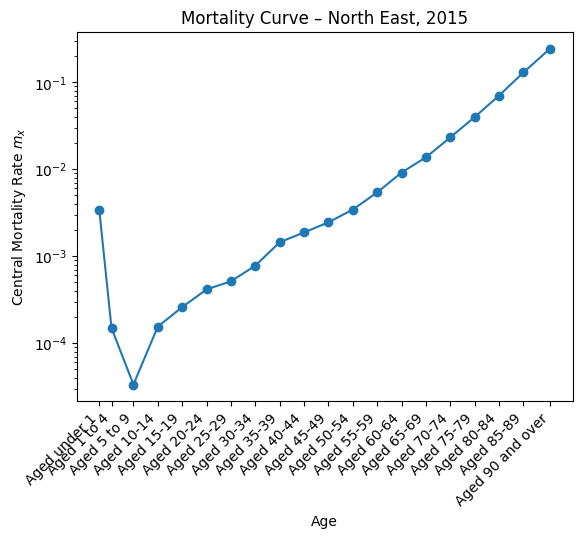

In [4]:
# We need to convert the age bands into a numeric value for plotting. We will use the midpoint of each age band as a representative age.
def band_midpoint(band):
    if band == "Aged under 1":
        return 0
    if band == "Aged 90 and over":
        return 92.5
    nums = [int(s) for s in band.replace("Aged","").replace("to","-").replace("and over","").replace(" ","").split("-")]
    return sum(nums) / len(nums)

data["age_mid"] = data["age"].apply(band_midpoint)


sample = data[(data["year"]==2015) & (data["geo_name"]=="North East")] # here we take a sample for one year and one region to check the plot

sample = data[(data["year"] == 2015) &
              (data["geo_name"] == "North East") &
              (data["gender"] == 0)].copy()

sample = sample.sort_values("age_mid")


import matplotlib.pyplot as plt
plt.plot(sample["age_mid"], sample["mx"], marker="o")
plt.yscale("log")
plt.xlabel("Age")
plt.ylabel("Central Mortality Rate $m_x$")
plt.title("Mortality Curve – North East, 2015")
plt.xticks(sample["age_mid"], sample["age"], rotation=45, ha="right")
plt.show()



### Mortality Curve for North East, 2015
The plot below shows the central mortality rate $m_x$ across age groups for the North East region in 2015, using a logarithmic y‑axis. The curve follows the expected demographic pattern:
High infant mortality at “Aged under 1”.

- Sharp decline into early childhood (ages 1–9).
- Lowest mortality in late childhood and early teens.
- Gradual rise through young adulthood.
- Exponential increase in later life, consistent with Gompertz law.
- Steep rise in the oldest age groups (80+).

This shape confirms that the deaths and population datasets were merged correctly, the age‑band harmonisation worked, and the calculated $m_x$ values are consistent with known mortality behaviour. This validation step ensures the data is ready for constructing $q_x$, $l_x$ and the full life table.

### Probabilty of Death $q_x$

**Defintion** 

$q_x$ represents the **probability that an individual aged $x$ will die before reaching age $x+n$, where $n$ is the width of the age band. Unlike the central mortality rate $m_x$, which is the rate. $q_x is a true probabilty bounded between 0 and 1. It captures the risk of death over the entire age interval and forms the basis of life table construction.

### Deriving $q_x$ from $m_x$

Mortality data is grouped into age bands (e.g.,5-9,10-14), so we use a standard actuarial approximation to convert the central mortality rate into a probability:

$$ 
q_x = \frac{n \cdot m_x }{1+(n-a_x) \cdot m_x}
$$

Where in our case:
- $n$ is the width of the age band
  - typically 5 years for most adult bands
  - 1 year for “Aged under 1”
  - open-ended for “Aged 90 and over”

- $a_x$ is the average time lived in the interval by those who die
  - usually 0.1 for infants
  - 2.5 for standard 5‑year bands
  - 1 for the final open-ended age group

This formula adjusts for the fact that deaths occur throughout the interval rather than all at the start or end.


In [5]:
# calculate q_x for all age bands

import numpy as np

# 1. Define band widths n_x
def band_width(band):
    if band == "Aged under 1":
        return 1
    if band == "Aged 90 and over":
        return 1   # treat final open-ended band as width 1
    nums = [int(s) for s in band.replace("Aged","").replace("to","-").replace("and over","").replace(" ","").split("-")]
    return nums[1] - nums[0] + 1

# 2. Define a_x (average time lived in interval by those who die)
def ax_value(band):
    if band == "Aged under 1":
        return 0.1
    if band == "Aged 90 and over":
        return 1
    return 2.5   # standard assumption for 5-year bands

# 3. Apply both functions
sample["n"] = sample["age"].apply(band_width)
sample["ax"] = sample["age"].apply(ax_value)

# 4. Compute q_x using the actuarial approximation
sample["qx"] = (sample["n"] * sample["mx"]) / (1 + (sample["n"] - sample["ax"]) * sample["mx"])



In [6]:
# compute p_x probability of surviving the 
# p_x = 1 - q_x
sample["px"] = 1 - sample["qx"]


$p_x$ is the probabilty of **surviving** the age interval

In [7]:
# compute l_x number of survivors at each age

# choose a radix (starting population)
l0 = 100000

# create l_x column
lx = [l0]

for i in range(1, len(sample)):
    lx.append(lx[i-1] * sample["px"].iloc[i-1])

sample["lx"] = lx


- A life table starts with a radix, usually $l_0$ = 100000
- Each subsequent $l_x$ is the number of survivors after applying the survival probability from the previous interval:

$$ L_{x+n} = l_x \cdot p_x$$

This produces a decreasing sequence of survivors across the bands.

In [8]:
#compute d_x number of deaths in the interval

sample["dx"] = sample["lx"] - sample["lx"].shift(-1)


$d_x$ is the number of people who die between ages $x$ and $x+n$:
$$ d_x=l_x - l_{x+n} $$

In [9]:
# Compute L_x (person-years lived in the interval)
sample["Lx"] = sample["n"] * sample["lx"].shift(-1) + sample["ax"] * sample["dx"]


$L_x$ represents the **total person-years lived** in the interval.

The standard approximation is:

$$ L_x  = n\cdot l_{x+n} + a_x \cdot d_x $$

This accounts for 
- survivors who live in the full interval 
- deaths who live only part of it (weighted by $a_x$)


In [10]:
# compute T_x total future person-years 
sample["Tx"] = sample["Lx"][::-1].cumsum()[::-1]


$T_x$ is the total number of person-years lived from age $x$ onwards: 
$$ T_x = \sum_{y \ge x} L_y $$

This is a cumulative sum from the bottom of the table upward.

In [11]:
# compute e_x life expectancy at age x
sample["ex"] = sample["Tx"] / sample["lx"]

Life expectancy is:
$$ e_x = \frac{T_x}{l_x} $$

This gives the **expected remaing years of life** for someone aged $x$

In [12]:
# remove the nan from the last rows 

# Identify last row
last = sample.index[-1]

# 1. qx = 1 for final open-ended age band
sample.loc[last, "qx"] = 1

# 2. px = 0 (no one survives)
sample.loc[last, "px"] = 0

# 3. dx = lx (everyone dies)
sample.loc[last, "dx"] = sample.loc[last, "lx"]

# 4. Lx = lx / mx (open-ended approximation)
sample.loc[last, "Lx"] = sample.loc[last, "lx"] / sample.loc[last, "mx"]

# 5. Tx = Lx (no future intervals)
sample.loc[last, "Tx"] = sample.loc[last, "Lx"]

# 6. ex = Tx / lx = 1 / mx
sample.loc[last, "ex"] = 1 / sample.loc[last, "mx"]


In [13]:
sample[["age", "mx", "qx", "px", "lx", "dx", "Lx", "Tx", "ex"]]


,age,mx,qx,px,lx,dx,Lx,Tx,ex
0,Aged under 1,0.003360,0.003349,0.996651,100000.000000,334.937508,99698.556243,7.876381e+06,78.763809
1,Aged 1 to 4,0.000149,0.000596,0.999404,99665.062492,59.387286,398571.169041,7.776682e+06,78.028169
2,Aged 5 to 9,0.000033,0.000167,0.999833,99605.675207,16.625163,497986.813125,7.378111e+06,74.073201
3,Aged 10-14,0.000155,0.000773,0.999227,99589.050043,76.959623,497752.851161,6.880124e+06,69.085149
4,Aged 15-19,0.000259,0.001294,0.998706,99512.090421,128.746575,497238.585666,6.382372e+06,64.136644
5,Aged 20-24,0.000413,0.002065,0.997935,99383.343845,205.235152,496403.631346,5.885133e+06,59.216492
6,Aged 25-29,0.000513,0.002564,0.997436,99178.108693,254.293528,495254.809645,5.388729e+06,54.333859
7,Aged 30-34,0.000775,0.003866,0.996134,98923.815165,382.397689,493663.081602,4.893475e+06,49.467103
8,Aged 35-39,0.001444,0.007192,0.992808,98541.417476,708.745214,490935.224344,4.399811e+06,44.649362
9,Aged 40-44,0.001868,0.009298,0.990702,97832.672262,909.599751,486889.361932,3.908876e+06,39.954712


### Life Table Summary

The completed life table provides a full description of mortality and survival patterns for  robability of dying in each age interval, while the $l_x$ column tracks the number of survivors from an initial cohort of 100,000 lives. The $L_x$ and $T_x$ columns measure total person‑years lived, and the final column $e_x$ gives the expected remaining lifetime at each age.

Life expectancy at birth $e_0$ is a key output of the table and summarises overall mortality conditions for the population in that year.


In [20]:
e0 = sample.loc[sample["age"] == "Aged under 1", "ex"].values[0]
e65 = sample.loc[sample["age"] == "Aged 65-69", "ex"].values[0]

print("Life expectancy at birth:", e0)
print("Life expectancy at age 65:", e65)


Life expectancy at birth: 78.76380936432487
Life expectancy at age 65: 17.746671461848702


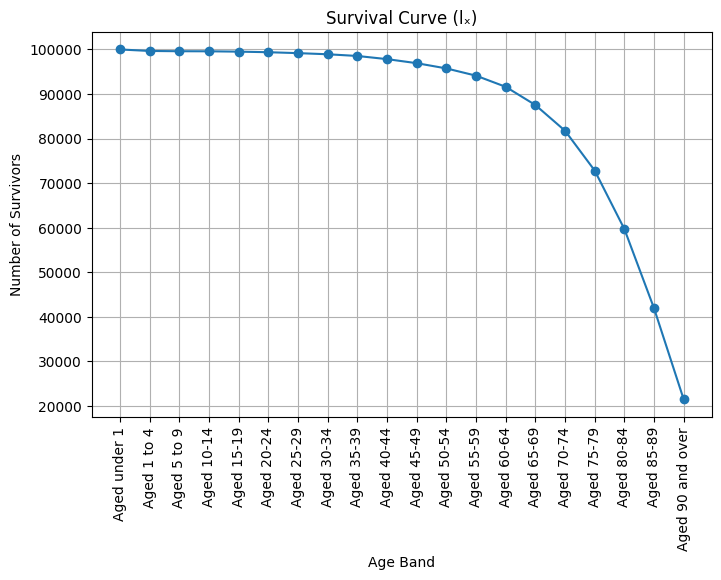

In [23]:
# plot of survival curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(sample["age"], sample["lx"], marker="o")
plt.xticks(rotation=90)
plt.title("Survival Curve (lₓ)")
plt.ylabel("Number of Survivors")
plt.xlabel("Age Band")
plt.grid(True)
plt.savefig("../figures/survival_curve.png", bbox_inches="tight")
plt.show()


The survival curve shows that mortality in the North East in 2015 is very low through childhood and early adulthood, with the cohort remaining close to its initial size until around age 50. Survival then declines more noticeably through mid‑life and drops sharply after age 70, leaving roughly one‑fifth of the original cohort alive by the 90+ age band. This pattern is consistent with typical UK demographic profiles.

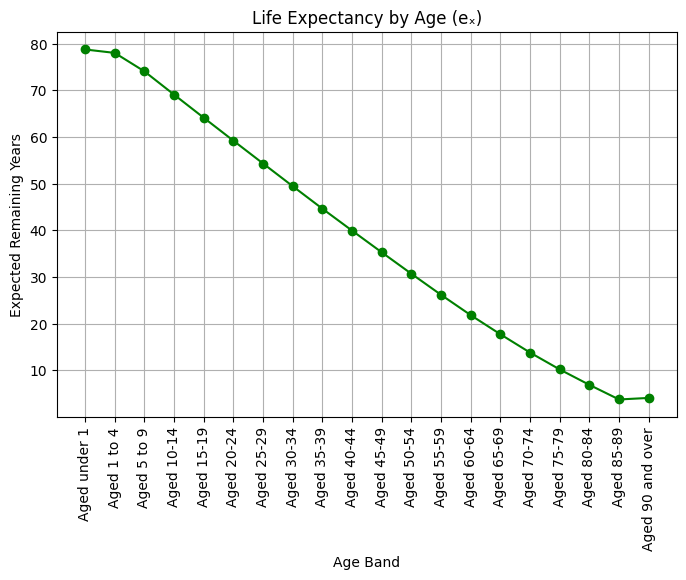

In [24]:
# plot the life expectancy curve
plt.figure(figsize=(8,5))
plt.plot(sample["age"], sample["ex"], marker="o", color="green")
plt.xticks(rotation=90)
plt.title("Life Expectancy by Age (eₓ)")
plt.ylabel("Expected Remaining Years")
plt.xlabel("Age Band")
plt.grid(True)
plt.savefig("../figures/life_expectancy_curve.png", bbox_inches="tight")
plt.show()


The life expectancy curve decreases smoothly with age, starting at around 78.8 years at birth and falling more rapidly in older ages as mortality accelerates. Remaining life expectancy at age 65 is approximately 17.8 years, implying an expected age at death of around 82–83. These values align with published ONS estimates for the region and period, indicating that the constructed life table reflects realistic mortality conditions.

### Summary 
This notebook constructed a complete period life table for the North East region in 2015 using raw deaths and population data. After calculating central mortality rates $m_x$ and converting them into death probabilities $q_x$, the full set of life table columns ($p_x,l_X,d_X,L_x,T_x,e_x$) was derived. The table describes survival patterns across age groups and provides key demographic indicators such as life expectancy.

### Results
The life table indicates a life expectancy at birth of 78.8 years, which is consistent with ONS estimates for the North East around this period (typically around 79–80 years). Life expectancy at age 65 is 17.8 years, meaning a 65‑year‑old can expect to live to approximately age 82–83. The survival pattern follows the expected demographic shape: low mortality in childhood, gradually increasing mortality through adulthood, and a steep rise at older ages.

These results reflect the demographic characteristics of the North East in 2015, including relatively higher mortality compared with southern regions of England. The life table provides a foundation for applications such as annuity pricing, pension valuation, and longevity analysis.
